In [3]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [4]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [5]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [6]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [7]:
len(dataset) #it states 68 because every element in the dataset is a batch of 32 images

68

In [8]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(32, 256, 256, 3)
[1 1 1 1 1 1 1 1 0 2 0 1 0 0 2 2 0 0 0 0 1 1 1 1 1 1 0 1 0 0 0 0]


In [9]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch[0]) #print the first image

tf.Tensor(
[[[104. 105. 125.]
  [109. 110. 130.]
  [125. 126. 146.]
  ...
  [132. 133. 151.]
  [138. 139. 157.]
  [128. 129. 147.]]

 [[136. 137. 157.]
  [101. 102. 122.]
  [ 93.  94. 114.]
  ...
  [117. 118. 136.]
  [114. 115. 133.]
  [126. 127. 145.]]

 [[116. 117. 137.]
  [109. 110. 130.]
  [108. 109. 129.]
  ...
  [127. 128. 146.]
  [118. 119. 137.]
  [117. 118. 136.]]

 ...

 [[172. 173. 191.]
  [165. 166. 184.]
  [163. 164. 182.]
  ...
  [201. 203. 215.]
  [200. 202. 214.]
  [208. 210. 222.]]

 [[173. 174. 192.]
  [171. 172. 190.]
  [159. 160. 178.]
  ...
  [177. 179. 191.]
  [185. 187. 199.]
  [212. 214. 226.]]

 [[147. 148. 166.]
  [169. 170. 188.]
  [154. 155. 173.]
  ...
  [185. 187. 199.]
  [179. 181. 193.]
  [195. 197. 209.]]], shape=(256, 256, 3), dtype=float32)


In [10]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch[0].shape) #print the shape of the first image

(256, 256, 3)


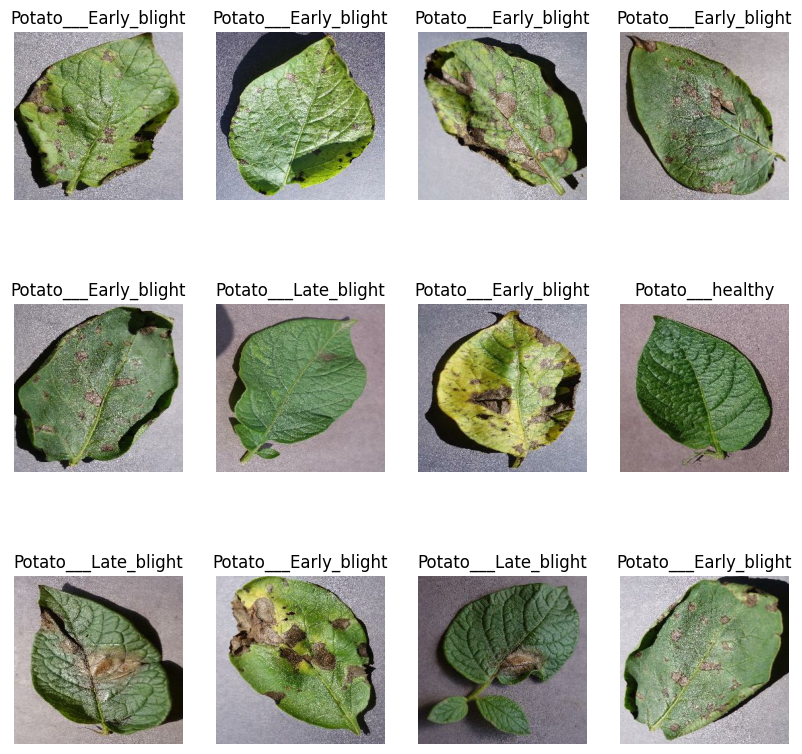

In [11]:
plt.figure(figsize=(10, 10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off") #this removes the axis

In [10]:
80% ==> training
20% ==> 10% validation, 10% test #at the end of every epoch we use the validation dataset to do the validation, once we are done through 50 epochs then, we use the test dataset to measure the accuracy of the model

SyntaxError: invalid syntax (4130436252.py, line 1)

In [12]:
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [13]:
train_ds = dataset.take(54)
len(train_ds)

54

In [14]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [15]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [16]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [17]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [18]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [19]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [20]:
len(train_ds)

54

In [21]:
len(val_ds)

6

In [22]:
len(test_ds)

8

In [23]:
#caching will read the image from the disk, and for the next iteration when you need the same image, it will keep that image in memory. So, it improves the performance of your pipeline
#prefetch, if you are using GPU and CPU, if GPU is busy training, prefetch will load the next set of batch from your disk, and that will improve the performance

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE) #letting tensorflow determine how many batches to load while GPU is training
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE) #letting tensorflow determine how many batches to load while GPU is training
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE) #letting tensorflow determine how many batches to load while GPU is training

#these datasets are optimized for training performance. So the training will run fast


Preprocessing

In [24]:
#If you have worked on any image processing, the first thing you do is scaling
#the numpy array we saw before was between 0 to 255, so it is an RGB scale.
#You want to divide that by 255, so that you get a number between 0 and 1

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE), #our image size are already 256 by 256, why are we resizing them? This resizing and rescaling layer will go to our ultimate model and when we have a trained model and when it starts predicting, during prediction if you are supplying an image that is not 256 by 256. This will take care of resizing it 
    layers.Rescaling(1.0/255)
])

In [25]:
#use data augmentation to make our model robust
#Let's say you train a model using some images and then when you try predicting and the image that you supply is rotated/different in contrast. Then your model will not perform better. So, for that we use a concept of data augmentation. For instance, you have an original image in your training data set, you create four new images/training samples out of the original image by applying different transformation (horizontal flip, contrast, rotation, zoom). Then, you will use all five images for training. 

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

Model Building

In [26]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax') #we have 3 neurons and softmax is probability, so we will have 3 probabilities
])

model.build(input_shape=input_shape)

C:\Users\marag\tfvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 4, 4, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 2, 2, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [29]:
history = model.fit( #recording the history of every epoch in the history parameter
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 597ms/step - accuracy: 0.4694 - loss: 0.9338 - val_accuracy: 0.6042 - val_loss: 0.7594
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 32s 583ms/step - accuracy: 0.6605 - loss: 0.7128 - val_accuracy: 0.7656 - val_loss: 0.5340
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 632ms/step - accuracy: 0.7396 - loss: 0.5515 - val_accuracy: 0.8750 - val_loss: 0.4086
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 33s 618ms/step - accuracy: 0.8019 - loss: 0.4440 - val_accuracy: 0.8854 - val_loss: 0.3028
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 33s 605ms/step - accuracy: 0.8983 - loss: 0.2812 - val_accuracy: 0.9115 - val_loss: 0.2002
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 33s 611ms/step - accuracy: 0.9112 - loss: 0.2407 - val_accuracy: 0.8958 - val_loss: 0.2513
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 32s 600ms/step - accuracy: 0.9052 - loss: 0.2510 - val_accuracy: 0.8906 - val_loss: 0.2608
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 32s 600ms/step - accuracy: 0.9382 - loss: 0.1723 - val_accu

In [30]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - accuracy: 0.9396 - loss: 0.1769


In [31]:
scores

[0.18844029307365417, 0.94140625]

In [32]:
history

In [33]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [34]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [35]:
history.history['accuracy']

[0.5,
 0.6707175970077515,
 0.7667824029922485,
 0.8246527910232544,
 0.9033564925193787,
 0.9108796119689941,
 0.9189814925193787,
 0.9496527910232544,
 0.9548611044883728,
 0.9461805820465088,
 0.9554398059844971,
 0.9751157164573669,
 0.9646990895271301,
 0.9583333134651184,
 0.9797453880310059,
 0.9618055820465088,
 0.9762731194496155,
 0.984375,
 0.9704861044883728,
 0.9826388955116272,
 0.9837962985038757,
 0.9849537014961243,
 0.9849537014961243,
 0.9745370149612427,
 0.9716435074806213,
 0.9907407164573669,
 0.9918981194496155,
 0.9924768805503845,
 0.9820601940155029,
 0.9936342835426331,
 0.9907407164573669,
 0.9728009104728699,
 0.9913194179534912,
 0.9733796119689941,
 0.9895833134651184,
 0.9913194179534912,
 0.9971064925193787,
 0.9878472089767456,
 0.9861111044883728,
 0.9936342835426331,
 0.9722222089767456,
 0.9913194179534912,
 0.9953703880310059,
 0.9924768805503845,
 0.9936342835426331,
 0.9971064925193787,
 0.9704861044883728,
 0.9837962985038757,
 0.97974538803100

In [36]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

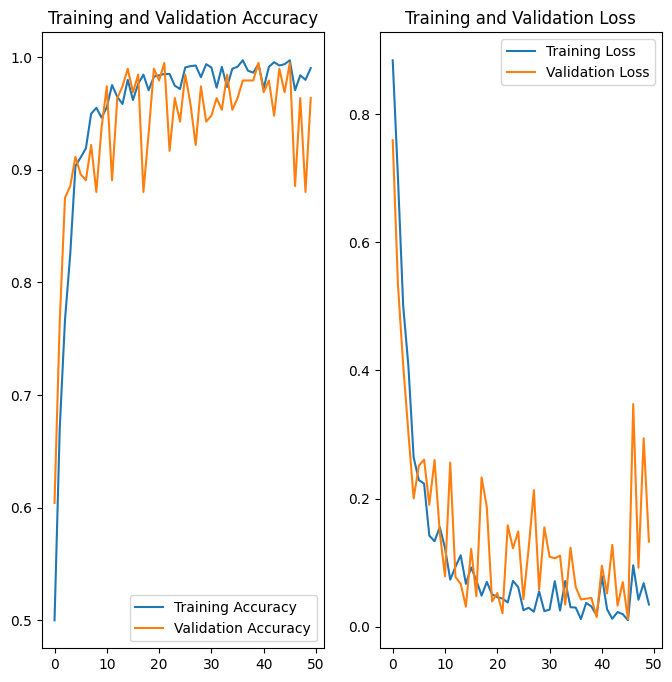

In [37]:
plt.figure(figsize=(8,8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [38]:
import numpy as np

np.argmax([1.0000000e+00, 3.0661515e-10, 1.0435155e-22]) #returns max number

np.int64(0)

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
predicted label: Potato___Late_blight


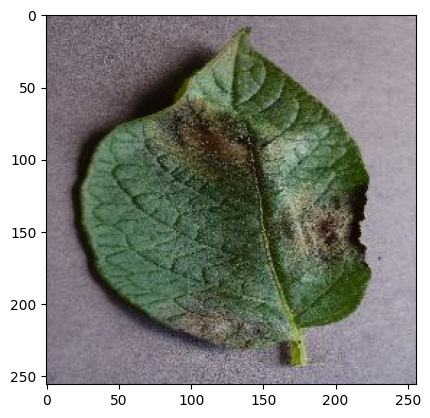

In [39]:
for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:", class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:", class_names[np.argmax(batch_prediction[0])])

In [40]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) #create a batch
    
    predictions = model.predict(img_array)
    
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.argmax(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


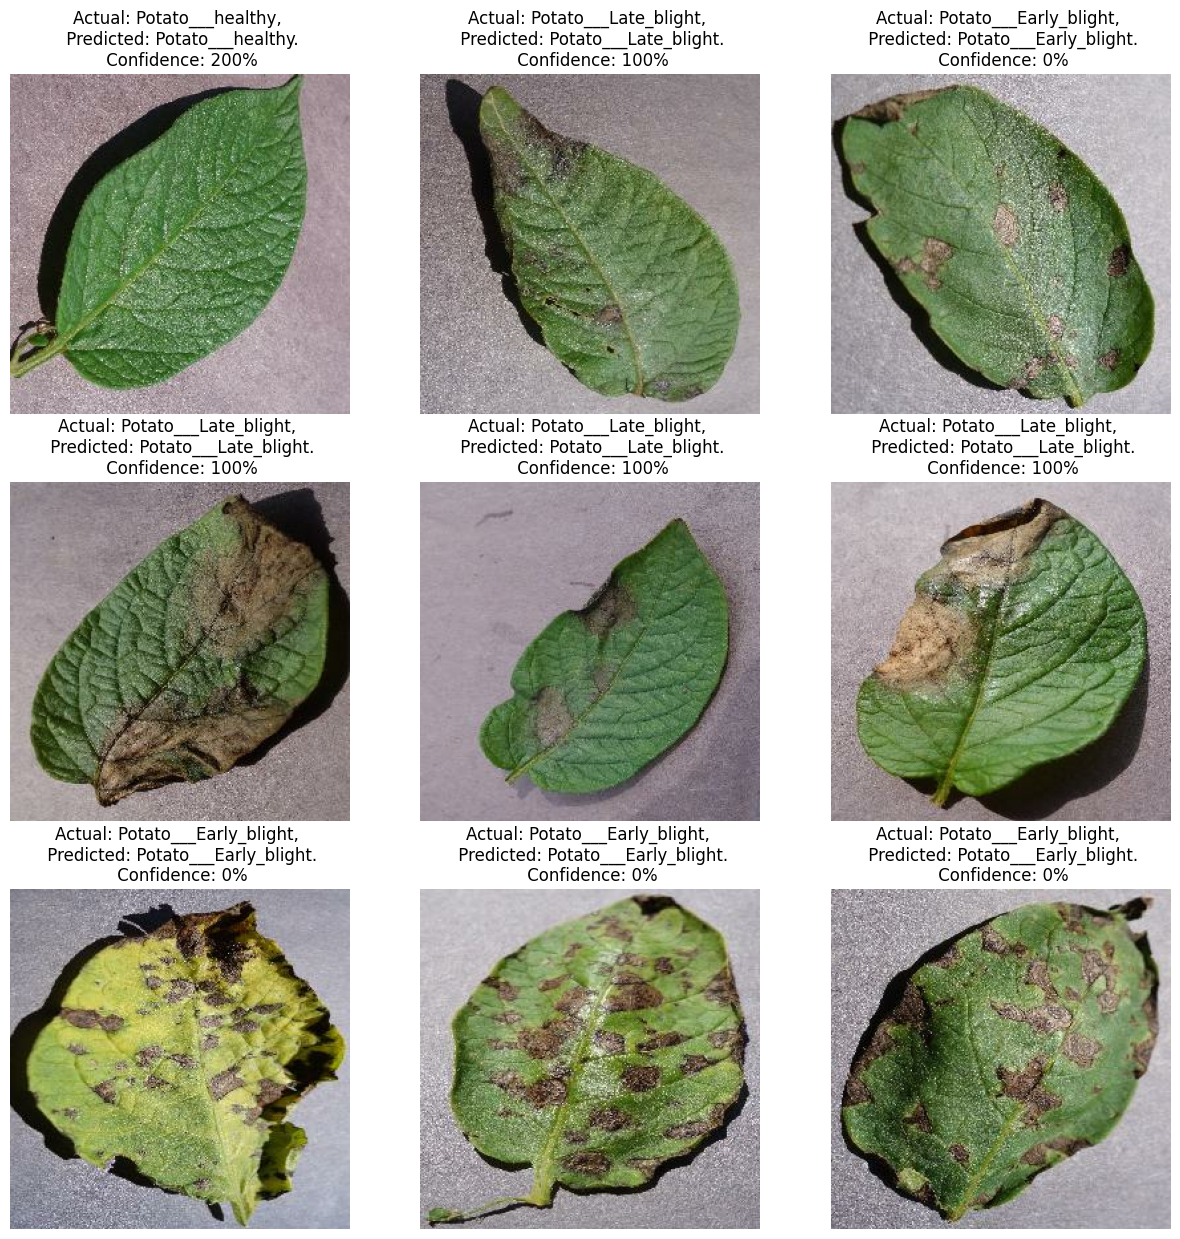

In [41]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]
        
        plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        plt.axis("off")

In [44]:
model.export("../saved_models/3")

INFO:tensorflow:Assets written to: ../saved_models/3\assets


INFO:tensorflow:Assets written to: ../saved_models/3\assets


Saved artifact at '../saved_models/3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2515783734992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2515783744016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2515791299792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2515791300560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2515791298832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2515791299216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2515791301712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2515791300944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2515791300752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2515791302672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2515791302480: TensorSpec(shape=(

In [45]:
import os
model_version = max([int(i) for i in os.listdir("../models") + [0]])+1
model.save(f"../saved_models/{model_version}")

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../models'

In [43]:
model_version = 3
model.save(f"../saved_models/{model_version}.keras")